In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

tf.random.set_seed(42)
np.random.seed(42)


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os
import gzip
import urllib.request

DATA_DIR = 'emnist_data'
os.makedirs(DATA_DIR, exist_ok=True)

BASE_URL = 'https://huggingface.co/datasets/Royc30ne/emnist-balanced/resolve/main/'
FILES = [
    'emnist-balanced-train-images-idx3-ubyte.gz',
    'emnist-balanced-train-labels-idx1-ubyte.gz',
    'emnist-balanced-test-images-idx3-ubyte.gz',
    'emnist-balanced-test-labels-idx1-ubyte.gz',
    'emnist-balanced-mapping.txt',
]

for fname in FILES:
    fpath = os.path.join(DATA_DIR, fname)
    if not os.path.exists(fpath):
        print(f"Downloading {fname} ...")
        urllib.request.urlretrieve(BASE_URL + fname, fpath)
    else:
        print(f"{fname} already downloaded.")

print("Done.")


Done.


In [ ]:
def load_idx_images(path):
    with gzip.open(path, 'rb') as f:
        data = f.read()
    # IDX3 header: magic(4) num_images(4) rows(4) cols(4), big-endian
    num_images = int.from_bytes(data[4:8], 'big')
    rows = int.from_bytes(data[8:12], 'big')
    cols = int.from_bytes(data[12:16], 'big')
    images = np.frombuffer(data[16:], dtype=np.uint8).reshape(num_images, rows, cols)
    return images

def load_idx_labels(path):
    with gzip.open(path, 'rb') as f:
        data = f.read()
    num_labels = int.from_bytes(data[4:8], 'big')
    labels = np.frombuffer(data[8:], dtype=np.uint8).reshape(num_labels)
    return labels

X_train = load_idx_images(os.path.join(DATA_DIR, 'emnist-balanced-train-images-idx3-ubyte.gz'))
y_train = load_idx_labels(os.path.join(DATA_DIR, 'emnist-balanced-train-labels-idx1-ubyte.gz'))
X_test = load_idx_images(os.path.join(DATA_DIR, 'emnist-balanced-test-images-idx3-ubyte.gz'))
y_test = load_idx_labels(os.path.join(DATA_DIR, 'emnist-balanced-test-labels-idx1-ubyte.gz'))

# mapping.txt: "<label_index> <ascii_code>" -> build class_names in label order
mapping = {}
with open(os.path.join(DATA_DIR, 'emnist-balanced-mapping.txt')) as f:
    for line in f:
        idx, ascii_code = line.strip().split()
        mapping[int(idx)] = chr(int(ascii_code))

num_classes = len(mapping)
class_names = [mapping[i] for i in range(num_classes)]

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)
print("Number of classes:", num_classes)
print("Classes:", class_names)


Train shape: (112800, 28, 28) (112800,)
Test shape: (18800, 28, 28) (18800,)
Number of classes: 47
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']


In [ ]:
IMG_SIZE = 28

def fix_orientation(images):
    # raw EMNIST images need a transpose to read correctly
    return np.transpose(images, (0, 2, 1))

X_train = fix_orientation(X_train)
X_test = fix_orientation(X_test)

X_train = (X_train.astype('float32') / 255.0).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
X_test = (X_test.astype('float32') / 255.0).reshape(-1, IMG_SIZE, IMG_SIZE, 1)

y_train = y_train.astype('int64')
y_test = y_test.astype('int64')


In [ ]:
from sklearn.model_selection import train_test_split

X_train_full, y_train_full = X_train, y_train

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.10,
    stratify=y_train_full,   # keep class balance identical across the split
    random_state=42
)

print(f"Train: {X_train.shape[0]} samples")
print(f"Val:   {X_val.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples (held out completely until final evaluation)")


Train: 101520 samples
Val:   11280 samples
Test:  18800 samples (held out completely until final evaluation)


In [ ]:
BATCH_SIZE = 128

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


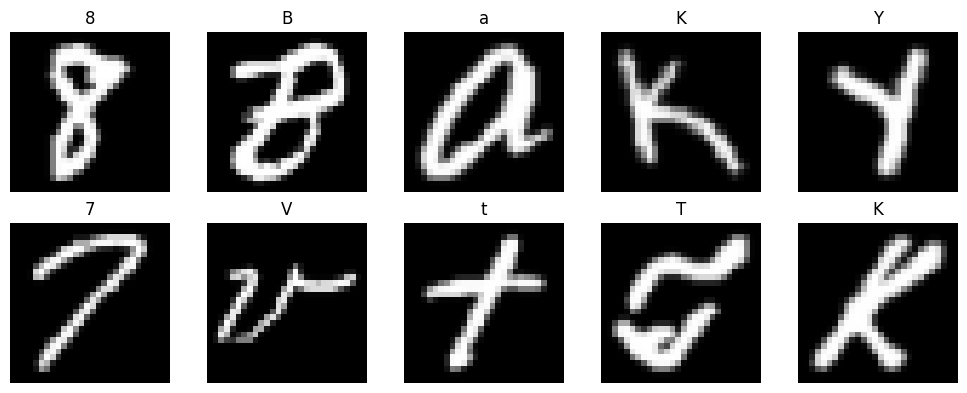

In [ ]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i].squeeze(), cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
def build_model(num_classes):
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = build_model(num_classes)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 47)             │        12,079 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 881,167 (3.36 MB)

 Trainable params: 880,655 (3.36 MB)

 Non-trainable params: 512 (2.00 KB)

In [ ]:
early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=4, restore_best_weights=True
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6
)

EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - accuracy: 0.7436 - loss: 0.8502 - val_accuracy: 0.8613 - val_loss: 0.4120 - learning_rate: 0.0010
Epoch 2/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.8408 - loss: 0.4703 - val_accuracy: 0.8776 - val_loss: 0.3470 - learning_rate: 0.0010
Epoch 3/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8582 - loss: 0.4118 - val_accuracy: 0.8831 - val_loss: 0.3258 - learning_rate: 0.0010
Epoch 4/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8654 - loss: 0.3843 - val_accuracy: 0.8860 - val_loss: 0.3254 - learning_rate: 0.0010
Epoch 5/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8700 - loss: 0.3665 - val_accuracy: 0.8848 - val_loss: 0.3188 - learning_rate: 0.0010
Epoch 6/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8756 - loss: 0.3477 - val_accuracy: 0.8895 - val_loss: 0.3165 - learning_rate: 0.0010
Epoch 7/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8793 - loss: 0.3362

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.06),        # ~±20 degrees
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomZoom(0.08),
], name="data_augmentation")

def build_augmented_model(num_classes):
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))
    x = data_augmentation(inputs)

    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs)

model_aug = build_augmented_model(num_classes)
model_aug.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_aug.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 47)             │        12,079 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 881,167 (3.36 MB)

 Trainable params: 880,655 (3.36 MB)

 Non-trainable params: 512 (2.00 KB)

In [ ]:
early_stop_aug = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=4, restore_best_weights=True
)
reduce_lr_aug = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6
)

history_aug = model_aug.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop_aug, reduce_lr_aug]
)


Epoch 1/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 22s 20ms/step - accuracy: 0.6507 - loss: 1.1746 - val_accuracy: 0.8383 - val_loss: 0.4933 - learning_rate: 0.0010
Epoch 2/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - accuracy: 0.7962 - loss: 0.6159 - val_accuracy: 0.8554 - val_loss: 0.4338 - learning_rate: 0.0010
Epoch 3/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.8147 - loss: 0.5461 - val_accuracy: 0.8676 - val_loss: 0.3777 - learning_rate: 0.0010
Epoch 4/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.8263 - loss: 0.5116 - val_accuracy: 0.8680 - val_loss: 0.3817 - learning_rate: 0.0010
Epoch 5/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.8307 - loss: 0.4911 - val_accuracy: 0.8748 - val_loss: 0.3648 - learning_rate: 0.0010
Epoch 6/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.8375 - loss: 0.4687 - val_accuracy: 0.8751 - val_loss: 0.3539 - learning_rate: 0.0010
Epoch 7/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.8412 - l

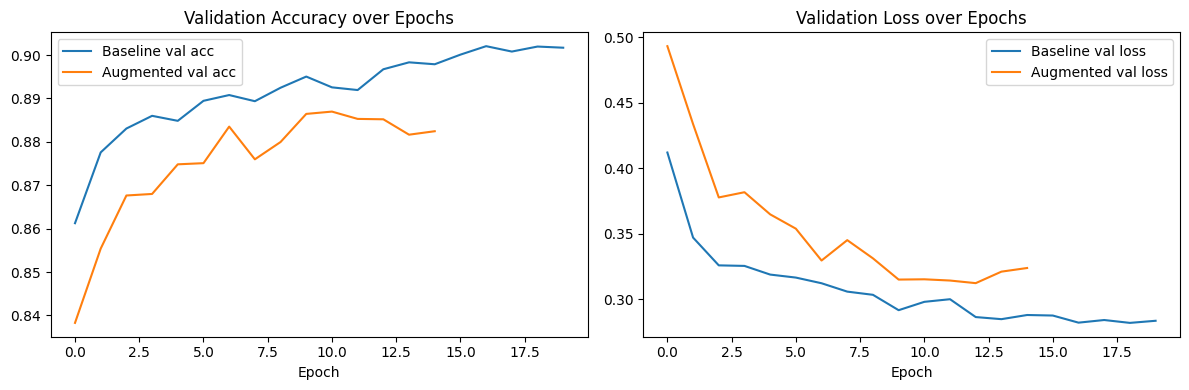

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['val_accuracy'], label='Baseline val acc')
axes[0].plot(history_aug.history['val_accuracy'], label='Augmented val acc')
axes[0].set_title('Validation Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['val_loss'], label='Baseline val loss')
axes[1].plot(history_aug.history['val_loss'], label='Augmented val loss')
axes[1].set_title('Validation Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
best_val_acc = max(history.history['val_accuracy'])
best_val_acc_aug = max(history_aug.history['val_accuracy'])

print(f"Baseline  — best validation accuracy: {best_val_acc*100:.2f}%")
print(f"Augmented — best validation accuracy: {best_val_acc_aug*100:.2f}%")

if best_val_acc_aug >= best_val_acc:
    final_model = model_aug
    final_model_name = "model_aug (augmented)"
else:
    final_model = model
    final_model_name = "model (baseline)"

print(f"\nSelected for deployment: {final_model_name}")


Baseline  — best validation accuracy: 90.20%
Augmented — best validation accuracy: 88.70%

Selected for deployment: model (baseline)


In [ ]:
test_loss, test_acc = final_model.evaluate(test_ds)
print(f"Final Model: {final_model_name}")
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9004 - loss: 0.2891
Final Model: model (baseline)
Test Accuracy: 90.04%
Test Loss: 0.2891


In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = final_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))


              precision    recall  f1-score   support

           0       0.65      0.77      0.71       400
           1       0.58      0.74      0.65       400
           2       0.93      0.89      0.91       400
           3       0.99      0.99      0.99       400
           4       0.96      0.95      0.95       400
           5       0.96      0.91      0.94       400
           6       0.94      0.94      0.94       400
           7       0.98      0.99      0.99       400
           8       0.96      0.97      0.96       400
           9       0.70      0.83      0.76       400
           A       0.98      0.99      0.99       400
           B       0.98      0.98      0.98       400
           C       0.97      0.96      0.97       400
           D       0.94      0.91      0.93       400
           E       0.99      0.98      0.99       400
           F       0.73      0.62      0.67       400
           G       0.93      0.96      0.94       400
           H       0.98    

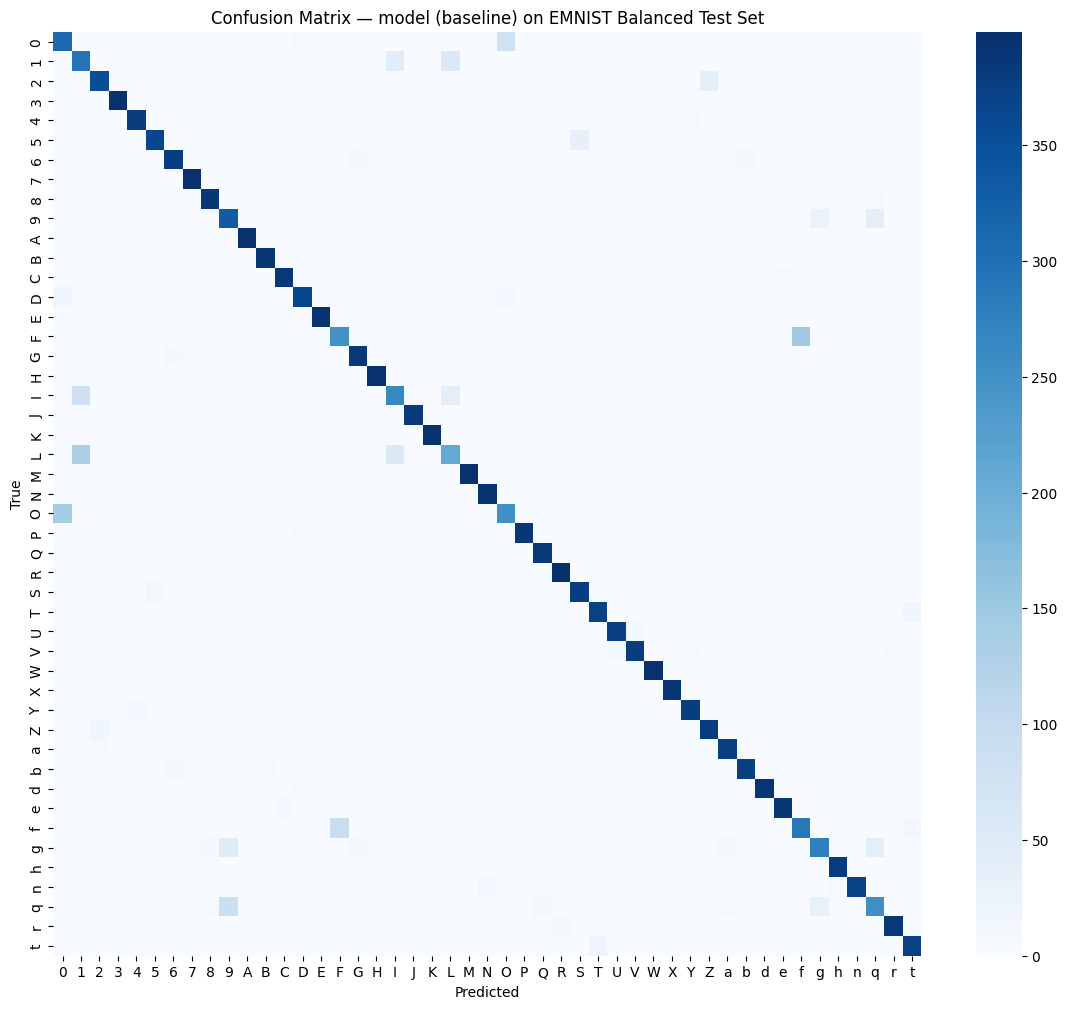

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix — {final_model_name} on EMNIST Balanced Test Set')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


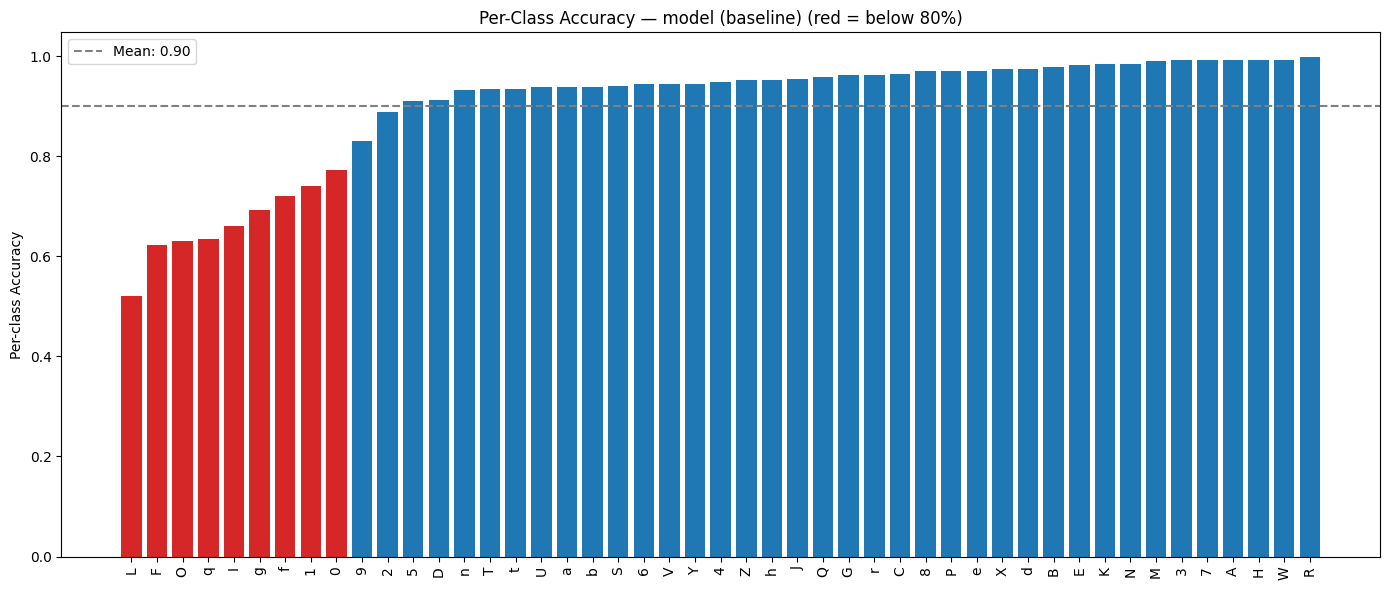

Weakest 5 classes:
  L: 52.0%
  F: 62.3%
  O: 63.0%
  q: 63.5%
  I: 66.0%

Strongest 5 classes:
  7: 99.2%
  A: 99.2%
  H: 99.2%
  W: 99.2%
  R: 99.8%


In [ ]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

acc_df = list(zip(class_names, per_class_acc))
acc_df.sort(key=lambda x: x[1])  # weakest first

labels_sorted = [x[0] for x in acc_df]
acc_sorted = [x[1] for x in acc_df]

plt.figure(figsize=(14, 6))
colors = ['#d62728' if a < 0.80 else '#1f77b4' for a in acc_sorted]
plt.bar(labels_sorted, acc_sorted, color=colors)
plt.axhline(y=np.mean(acc_sorted), color='gray', linestyle='--', label=f'Mean: {np.mean(acc_sorted):.2f}')
plt.xticks(rotation=90)
plt.ylabel('Per-class Accuracy')
plt.title(f'Per-Class Accuracy — {final_model_name} (red = below 80%)')
plt.legend()
plt.tight_layout()
plt.show()

print("Weakest 5 classes:")
for name, acc in acc_df[:5]:
    print(f"  {name}: {acc*100:.1f}%")
print("\nStrongest 5 classes:")
for name, acc in acc_df[-5:]:
    print(f"  {name}: {acc*100:.1f}%")


### Visualize Sample Predictions

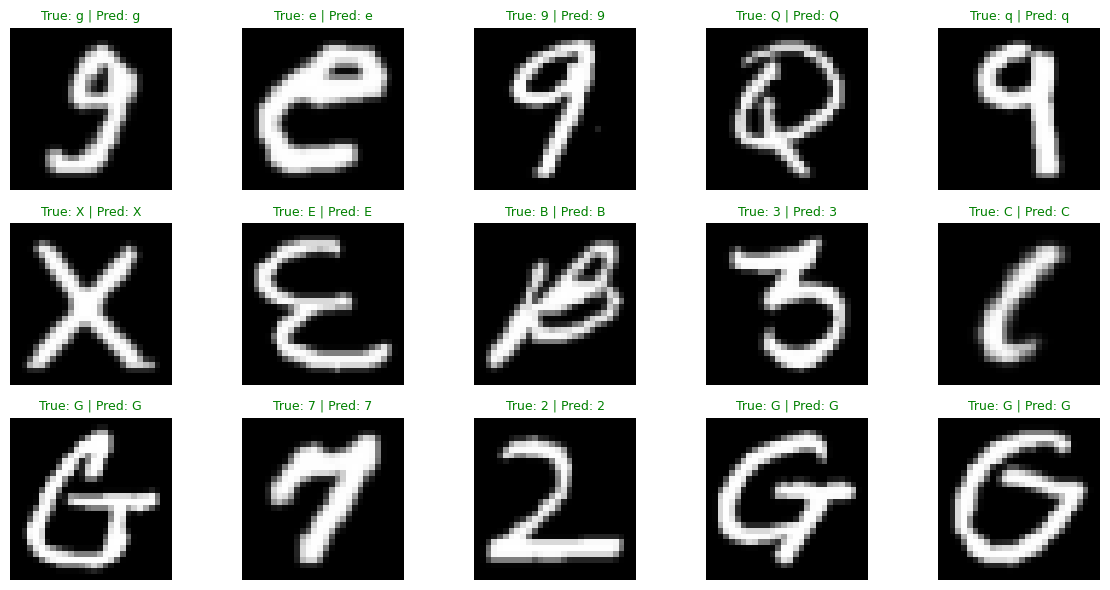

In [ ]:
plt.figure(figsize=(12, 6))
for images, labels in test_ds.take(1):
    preds = final_model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)
    for i in range(15):
        plt.subplot(3, 5, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap='gray')
        true_c = class_names[labels[i].numpy()]
        pred_c = class_names[pred_labels[i]]
        color = 'green' if true_c == pred_c else 'red'
        plt.title(f"True: {true_c} | Pred: {pred_c}", color=color, fontsize=9)
        plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
final_model.save('handwritten_character_recognition_emnist.keras')
print(f"Saved: handwritten_character_recognition_emnist.keras ({final_model_name})")

# Optional: download directly from Colab
from google.colab import files
files.download('handwritten_character_recognition_emnist.keras')


Saved: handwritten_character_recognition_emnist.keras (model (baseline))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saving Screenshot 2026-08-18 131802.png to Screenshot 2026-08-18 131802.png
Using: model (baseline)


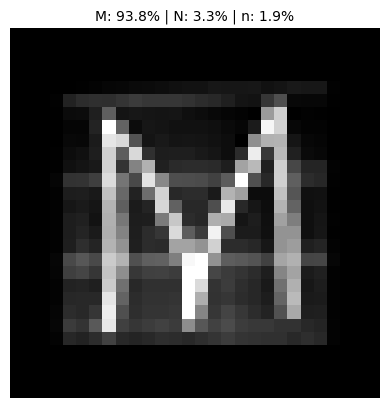

In [ ]:
from google.colab import files
from PIL import Image, ImageOps
import numpy as np

def preprocess_uploaded_character(img: Image.Image) -> np.ndarray:
    '''Take an arbitrary photo of a single handwritten character and
    return a (1, 28, 28, 1) array ready for the model, matching EMNIST's
    white-strokes-on-black convention.'''
    img = img.convert('L')

    # Stretch contrast BEFORE anything else: phone photos of pen/pencil on
    # paper often have ink that's only mid-gray (shadows, uneven lighting,
    # faint pencil), whereas EMNIST's training images are high-contrast
    # (near-pure black background, near-pure white strokes). Autocontrast
    # remaps the image's own darkest -> 0 and brightest -> 255, closing
    # that gap without fully binarizing (which would lose the soft
    # anti-aliased edges the model was trained on).
    img = ImageOps.autocontrast(img, cutoff=2)

    # Auto-detect polarity: EMNIST is white-on-black. If the image looks
    # light (mean pixel > 127), assume it's black-on-white (e.g. pen on
    # paper) and invert it.
    if np.array(img).mean() > 127:
        img = ImageOps.invert(img)

    arr = np.array(img)

    # Crop to the character's bounding box (ignore near-black background)
    mask = arr > 30
    if mask.any():
        rows = np.any(mask, axis=1)
        cols = np.any(mask, axis=0)
        r0, r1 = np.where(rows)[0][[0, -1]]
        c0, c1 = np.where(cols)[0][[0, -1]]
        arr = arr[r0:r1+1, c0:c1+1]

    # Pad to square, then add margin so the character isn't touching the edges
    h, w = arr.shape
    size = max(h, w)
    pad_h, pad_w = (size - h) // 2, (size - w) // 2
    arr = np.pad(arr, ((pad_h, size - h - pad_h), (pad_w, size - w - pad_w)))
    margin = size // 5
    arr = np.pad(arr, margin)

    img = Image.fromarray(arr).resize((28, 28))

    # Second contrast stretch after crop+resize: the crop may have
    # discarded the darkest/brightest pixels that anchored the first
    # stretch (e.g. background paper texture outside the bounding box),
    # so re-stretching on just the final 28x28 crop sharpens it further.
    img = ImageOps.autocontrast(img, cutoff=1)

    arr = np.array(img).astype('float32') / 255.0
    return arr.reshape(1, 28, 28, 1)


def predict_character(arr: np.ndarray, model, top_k: int = 3):
    preds = model.predict(arr, verbose=0)[0]
    top_idx = preds.argsort()[-top_k:][::-1]
    return [(class_names[i], float(preds[i]) * 100) for i in top_idx]


uploaded = files.upload()  # upload photo(s) of handwritten characters

print(f"Using: {final_model_name}")

for fname in uploaded.keys():
    raw_img = Image.open(fname)
    arr = preprocess_uploaded_character(raw_img)
    top3 = predict_character(arr, final_model, top_k=3)

    plt.imshow(arr.squeeze(), cmap='gray')
    title = " | ".join([f"{c}: {p:.1f}%" for c, p in top3])
    plt.title(title, fontsize=10)
    plt.axis('off')
    plt.show()


In [ ]:
# Persist the class mapping alongside the model so inference doesn't
# depend on re-deriving it from the dataset.
import json

with open('class_names.json', 'w') as f:
    json.dump(class_names, f)

# Save the final model (already selected by validation accuracy and
# evaluated once on the test set in Section 8) as the deployment artifact.
final_model.save('handwritten_character_recognition_deploy.keras')
print(f"Saved deployment artifacts ({final_model_name}): "
      "handwritten_character_recognition_deploy.keras, class_names.json")


Saved deployment artifacts (model (baseline)): handwritten_character_recognition_deploy.keras, class_names.json


In [ ]:
%%writefile inference.py
"""
Standalone inference module for the CodeAlpha handwritten character
recognition model. Usage:

    from inference import HandwritingClassifier
    clf = HandwritingClassifier('handwritten_character_recognition_deploy.keras',
                                 'class_names.json')
    predictions = clf.predict('path/to/photo.png')
"""
import json
import numpy as np
import tensorflow as tf
from PIL import Image, ImageOps


class HandwritingClassifier:
    def __init__(self, model_path: str, class_names_path: str):
        self.model = tf.keras.models.load_model(model_path)
        with open(class_names_path) as f:
            self.class_names = json.load(f)

    @staticmethod
    def _preprocess(img: Image.Image) -> np.ndarray:
        img = img.convert('L')

        # Stretch contrast first: phone-photo ink is often mid-gray rather
        # than the near-pure black/white EMNIST was trained on.
        img = ImageOps.autocontrast(img, cutoff=2)

        if np.array(img).mean() > 127:
            img = ImageOps.invert(img)
        arr = np.array(img)

        mask = arr > 30
        if mask.any():
            rows, cols = np.any(mask, axis=1), np.any(mask, axis=0)
            r0, r1 = np.where(rows)[0][[0, -1]]
            c0, c1 = np.where(cols)[0][[0, -1]]
            arr = arr[r0:r1 + 1, c0:c1 + 1]

        h, w = arr.shape
        size = max(h, w)
        pad_h, pad_w = (size - h) // 2, (size - w) // 2
        arr = np.pad(arr, ((pad_h, size - h - pad_h), (pad_w, size - w - pad_w)))
        margin = size // 5
        arr = np.pad(arr, margin)

        img = Image.fromarray(arr).resize((28, 28))
        img = ImageOps.autocontrast(img, cutoff=1)  # re-stretch the final crop
        arr = np.array(img).astype('float32') / 255.0
        return arr.reshape(1, 28, 28, 1)

    def predict(self, image_path: str, top_k: int = 3):
        img = Image.open(image_path)
        arr = self._preprocess(img)
        preds = self.model.predict(arr, verbose=0)[0]
        top_idx = preds.argsort()[-top_k:][::-1]
        return [
            {"character": self.class_names[i], "confidence": float(preds[i])}
            for i in top_idx
        ]


if __name__ == "__main__":
    import sys
    clf = HandwritingClassifier(
        "handwritten_character_recognition_deploy.keras", "class_names.json"
    )
    result = clf.predict(sys.argv[1])
    print(result)


Writing inference.py


In [ ]:
!pip install -q gradio
import gradio as gr
print("Gradio version:", gr.__version__)


Gradio version: 6.24.0


In [ ]:
import traceback
from inference import HandwritingClassifier

clf = HandwritingClassifier(
    "handwritten_character_recognition_deploy.keras", "class_names.json"
)

def extract_sketch_array(sketch):
    '''Handle multiple possible Sketchpad return formats across Gradio versions.'''
    if sketch is None:
        return None
    if isinstance(sketch, np.ndarray):
        return sketch
    if isinstance(sketch, dict):
        # Newer Gradio: {'background': ..., 'layers': [...], 'composite': ...}
        for key in ("composite", "background"):
            if key in sketch and sketch[key] is not None:
                return sketch[key]
        # Fall back to the first non-empty layer
        layers = sketch.get("layers")
        if layers:
            for layer in layers:
                if layer is not None:
                    return layer
    raise ValueError(f"Unrecognized sketch format: {type(sketch)} — keys: "
                      f"{list(sketch.keys()) if isinstance(sketch, dict) else 'n/a'}")


def classify_sketch(sketch):
    try:
        arr_raw = extract_sketch_array(sketch)
        if arr_raw is None:
            return {}

        img = Image.fromarray(arr_raw).convert("L")
        arr = clf._preprocess(img)
        preds = clf.model.predict(arr, verbose=0)[0]
        top_idx = preds.argsort()[-5:][::-1]
        return {clf.class_names[i]: float(preds[i]) for i in top_idx}
    except Exception as e:
        # Surface the error in the UI instead of hanging or failing silently
        traceback.print_exc()
        return {f"Error: {type(e).__name__}": 1.0}

demo = gr.Interface(
    fn=classify_sketch,
    inputs=gr.Sketchpad(label="Draw a digit or letter"),
    outputs=gr.Label(num_top_classes=5, label="Predictions"),
    title="CodeAlpha — Handwritten Character Recognition",
    description="Draw a single digit (0-9) or letter (A-Z, a-z subset) and see the model's top predictions."
)

demo.queue()  # explicit queueing helps avoid stuck/hung requests on shared Colab tunnels
demo.launch(share=True, debug=True)  # debug=True prints tracebacks directly in this cell's output


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://151679a876e40bd6a1.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
